# SQLite gaming revenue analysis

This notebook **reads** `data/gaming.sqlite` and walks through the retained official gaming data.
It does **not** download, parse, or write to the database.

- `gaming_results` holds operator or statewide observations we kept from collectors.
- `source_coverage` describes what each collector found (ok, partial, blocked, etc.).
- One logical period can have multiple `source_sha256` values when a regulator revises a report.
- Revenue definitions differ by state: GGR, AGR, taxable revenue, and net proceeds are **not** interchangeable.

In [1]:
from pathlib import Path
import sqlite3
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from variant_gaming.common import project_root
from variant_gaming.consolidate import (
    build_operator_revenue,
    build_state_period_revenue,
    dedupe_latest_observation,
)
from variant_gaming.storage import default_db_path

ROOT = project_root()
database_path = default_db_path(ROOT)
connection = sqlite3.connect(
    f"file:{database_path.as_posix()}?mode=ro",
    uri=True,
)
print(f"Database path: {database_path}")
print(f"Database size (bytes): {database_path.stat().st_size:,}")


Database path: C:\Users\Sean\VscProjects\researchOS\data\gaming.sqlite
Database size (bytes): 13,893,632


In [2]:
coverage = pd.read_sql_query("SELECT * FROM source_coverage", connection)
results = pd.read_sql_query("SELECT * FROM gaming_results", connection)

print(f"gaming_results rows: {len(results):,}")
print(f"states with rows: {results['state_code'].nunique()}")

rows_by_state_vertical = (
    results.groupby(["state_code", "vertical"], dropna=False)
    .size()
    .rename("row_count")
    .reset_index()
    .sort_values(["state_code", "vertical"])
)
display(rows_by_state_vertical)

period_span = (
    results.groupby(["state_code", "vertical"], dropna=False)
    .agg(earliest_period=("period_start", "min"), latest_period=("period_end", "max"))
    .reset_index()
    .sort_values(["state_code", "vertical"])
)
display(period_span)

non_ok_coverage = coverage.loc[coverage["status"] != "ok", ["state_code", "vertical", "status", "reason"]].copy()
display(non_ok_coverage.sort_values(["status", "state_code"]))

gaming_results rows: 18,582
states with rows: 19


,state_code,vertical,row_count
0,CT,online_casino,223
1,CT,online_sports_betting,174
2,DC,online_sports_betting,62
3,DE,online_casino,612
4,IA,online_sports_betting,1669
5,IL,online_sports_betting,891
6,IN,online_sports_betting,1025
7,LA,online_sports_betting,55
8,MA,online_sports_betting,291
9,MD,online_sports_betting,351


,state_code,vertical,earliest_period,latest_period
0,CT,online_casino,2021-10-01,2026-07-31
1,CT,online_sports_betting,2021-10-01,2026-07-31
2,DC,online_sports_betting,2024-07-01,2026-07-31
3,DE,online_casino,2013-11-01,2026-07-31
4,IA,online_sports_betting,2019-08-01,2026-07-31
5,IL,online_sports_betting,2020-03-01,2026-06-30
6,IN,online_sports_betting,2019-10-01,2026-07-31
7,LA,online_sports_betting,2021-07-01,2026-07-31
8,MA,online_sports_betting,2023-03-01,2026-07-31
9,MD,online_sports_betting,2024-08-01,2026-07-31


,state_code,vertical,status,reason
33,OR,online_sports_betting,annual_only,Official public reporting is mainly annual/summary rather than a clean monthly archive (HTTP 200). Annual frequency recorded as acceptable coverage.
16,AZ,online_sports_betting,blocked,Official reports landing blocked for automated clients (HTTP 403; Cloudflare/captcha interstitial). No revenue upsert.
34,DE,online_sports_betting,blocked,"Official tables split casino sportsbooks vs Sports Lottery retailers, not online vs retail; not normalized as channel=online"
19,KY,online_sports_betting,blocked,Current sports wagering market report is Tableau-only; per project rules do not scrape chart pixels. No CSV/Excel export discovered.
27,WY,online_sports_betting,blocked_or_unavailable_export,Combined wagering activity landing returned no discoverable PDF/Excel export links (HTTP 200).
29,AR,online_sports_betting,combined_only,Official public landing does not expose an isolated online sports archive; DFA reporting may combine casino gaming and sports wagering.
30,NV,online_sports_betting,combined_only,Official GRI monthly PDFs provide sports-pool totals that do not cleanly isolate mobile. Channel must be treated as combined; not online-only. No online-only upsert.
21,ME,online_casino,legal_not_reporting,"I-Gaming authorized in law, but no official operating revenue reports found yet."
32,MT,location_based_mobile_sports_betting,location_based_mobile,Montana sports wagers are tied to sales-agent locations (location_based_mobile). Archive is news/PDF oriented; kept separate from unrestricted statewide mobile markets.
28,FL,online_sports_betting,not_publicly_available,No official monthly online sportsbook series on FGCC statistics page (slots/cardroom/pari-mutuel only). No third-party estimates used.


## Build current analytical views

We reuse `variant_gaming.consolidate` instead of inventing new rules in the notebook.

1. **Amendments must be deduplicated.** Official PDFs and Excel files get revised. `gaming_results` keeps every hash, but charts should use one latest observation per business key (`dedupe_latest_observation`).
2. **Do not blindly sum revenue across bases.** GGR, AGR, taxable revenue, and net proceeds measure different legal concepts.
3. **Keep `revenue_basis` on every chart and table.** The label prevents treating Massachusetts taxable gaming revenue as if it were another state's GGR.

In [3]:
latest_results = dedupe_latest_observation(results)
state_period = build_state_period_revenue(results)
operator_revenue = build_operator_revenue(results)

print(f"raw rows: {len(results):,} | after latest-observation dedupe: {len(latest_results):,}")
print(f"state-period rows: {len(state_period):,} | operator rows: {len(operator_revenue):,}")
revenue_basis_summary = (
    state_period["revenue_basis"]
    .value_counts(dropna=False)
    .rename("periods")
    .reset_index()
)
revenue_basis_summary.columns = ["revenue_basis", "periods"]
display(revenue_basis_summary)


raw rows: 18,582 | after latest-observation dedupe: 18,580
state-period rows: 2,270 | operator rows: 16,755


,revenue_basis,periods
0,GGR,1427
1,taxable_revenue,434
2,net_proceeds,292
3,AGR,76
4,NaN,41


In [4]:
latest_idx = state_period.groupby(["state_code", "vertical"])["period_start"].idxmax()
latest_overview = (
    state_period.loc[latest_idx]
    .loc[:, [
        "state_code",
        "vertical",
        "period_start",
        "handle",
        "revenue",
        "revenue_basis",
        "operator_count",
        "aggregation_source",
    ]]
    .rename(columns={"period_start": "latest_month", "revenue": "reported_revenue"})
    .sort_values(["state_code", "vertical"])
    .reset_index(drop=True)
)
display(latest_overview)


,state_code,vertical,latest_month,handle,reported_revenue,revenue_basis,operator_count,aggregation_source
0,CT,online_casino,2026-07-01,1.865517e+09,5.556381e+07,GGR,4,operator_sum
1,CT,online_sports_betting,2026-07-01,1.756544e+08,1.266224e+07,GGR,3,operator_sum
2,DC,online_sports_betting,2026-07-01,2.412010e+07,2.314579e+06,GGR,2,operator_sum
3,DE,online_casino,2026-07-01,3.584446e+08,1.343825e+07,net_proceeds,3,official_statewide_total
4,IA,online_sports_betting,2026-07-01,1.731755e+08,1.678639e+07,net_proceeds,19,official_statewide_total
5,IL,online_sports_betting,2026-06-01,1.121596e+09,8.941282e+07,AGR,16,official_statewide_total
6,IN,online_sports_betting,2026-07-01,3.776077e+08,4.080943e+07,GGR,11,official_statewide_total
7,LA,online_sports_betting,2026-07-01,2.692667e+08,3.331711e+07,net_proceeds,0,official_statewide_total
8,MA,online_sports_betting,2026-07-01,5.871019e+08,6.653061e+07,GGR,7,operator_sum
9,MD,online_sports_betting,2026-07-01,4.891599e+08,4.195000e+07,taxable_revenue,15,official_statewide_total


## Massachusetts online sportsbook walkthrough

Massachusetts publishes **Accrual Win** and **Taxable Gaming Revenue** as separate official fields.

- Accrual Win is stored in `gross_revenue` and is the reported gross-win measure before the federal-excise adjustment.
- Taxable Gaming Revenue remains in `taxable_revenue` as the adjusted state tax base.
- Hold uses Accrual Win divided by settled handle.
- With both handle and Accrual Win populated, MA is eligible for the strict monthly handle-plus-GGR cohort.


In [5]:
ma_operators = operator_revenue.loc[
    (operator_revenue["state_code"] == "MA")
    & (operator_revenue["vertical"] == "online_sports_betting")
].copy()

ma_monthly = (
    ma_operators.groupby("period_start", as_index=False)
    .agg(
        handle=("handle", "sum"),
        gross_revenue=("gross_revenue", "sum"),
        taxable_revenue=("taxable_revenue", "sum"),
        tax=("tax", "sum"),
        operator_count=("operator", "nunique"),
    )
)
ma_monthly["period_start"] = pd.to_datetime(ma_monthly["period_start"])
ma_monthly["gross_hold_pct"] = 100.0 * ma_monthly["gross_revenue"] / ma_monthly["handle"]
ma_monthly = ma_monthly.sort_values("period_start").reset_index(drop=True)

assert ma_monthly["gross_revenue"].notna().all(), "MA Accrual Win / gross_revenue must be populated"
display(ma_monthly.head(3))
display(ma_monthly.tail(3))


,period_start,handle,gross_revenue,taxable_revenue,tax,operator_count,gross_hold_pct
0,2023-03-01,5.481025e+08,46783507.41,45605606.68,9121121.34,6,8.535540
1,2023-04-01,5.662369e+08,59884578.33,58548295.26,11709653.81,6,10.575888
2,2023-05-01,4.435597e+08,60484866.70,59410840.40,11882168.06,8,13.636240


,period_start,handle,gross_revenue,taxable_revenue,tax,operator_count,gross_hold_pct
38,2026-05-01,6.249865e+08,71592104.28,70070108.76,14014021.76,7,11.454985
39,2026-06-01,6.089041e+08,55106651.55,53623096.13,10724619.23,7,9.050136
40,2026-07-01,5.871019e+08,66530607.93,65101989.55,13020397.81,7,11.332038


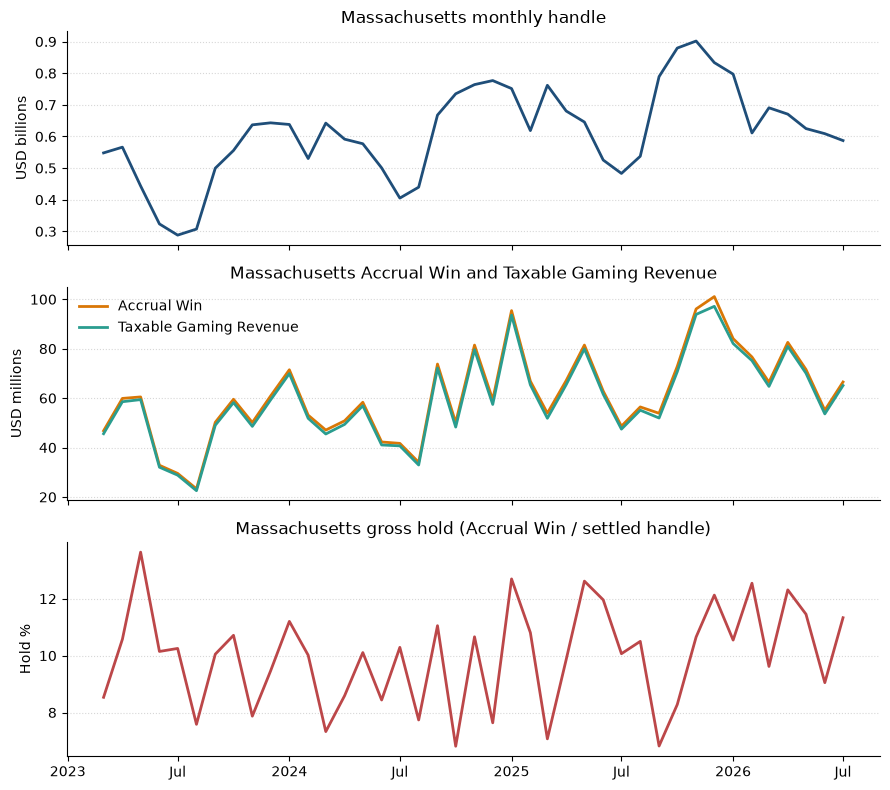

In [6]:
COLOR_HANDLE = "#1f4e79"
COLOR_ACCRUAL = "#d97706"
COLOR_TAXABLE = "#2a9d8f"
COLOR_HOLD = "#bc4749"

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)

axes[0].plot(ma_monthly["period_start"], ma_monthly["handle"] / 1e9, color=COLOR_HANDLE, linewidth=2)
axes[0].set_ylabel("USD billions")
axes[0].set_title("Massachusetts monthly handle")
axes[0].grid(axis="y", linestyle=":", alpha=0.5)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(
    ma_monthly["period_start"],
    ma_monthly["gross_revenue"] / 1e6,
    color=COLOR_ACCRUAL,
    linewidth=2,
    label="Accrual Win",
)
axes[1].plot(
    ma_monthly["period_start"],
    ma_monthly["taxable_revenue"] / 1e6,
    color=COLOR_TAXABLE,
    linewidth=2,
    label="Taxable Gaming Revenue",
)
axes[1].set_ylabel("USD millions")
axes[1].set_title("Massachusetts Accrual Win and Taxable Gaming Revenue")
axes[1].legend(frameon=False, loc="upper left")
axes[1].grid(axis="y", linestyle=":", alpha=0.5)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

axes[2].plot(
    ma_monthly["period_start"],
    ma_monthly["gross_hold_pct"],
    color=COLOR_HOLD,
    linewidth=2,
)
axes[2].set_ylabel("Hold %")
axes[2].set_title("Massachusetts gross hold (Accrual Win / settled handle)")
axes[2].grid(axis="y", linestyle=":", alpha=0.5)
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)

locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
locator.intervald[mdates.YEARLY] = [1, 2]
locator.intervald[mdates.MONTHLY] = [1, 2, 3, 4, 6]
formatter = mdates.ConciseDateFormatter(locator)
for axis in axes:
    axis.xaxis.set_major_locator(locator)
    axis.xaxis.set_major_formatter(formatter)

fig.tight_layout()
plt.show()


Latest Massachusetts reporting month: July 2026
July 2026 statewide: handle=$587,101,900.84; Accrual Win=$66,530,607.93; taxable=$65,101,989.55; gross hold=11.33%


,operator,handle,gross_revenue,taxable_revenue,handle_share_pct,gross_revenue_share_pct,taxable_revenue_share_pct,gross_hold_pct
0,DraftKings,2.811763e+08,33004446.68,32324402.68,47.892254,49.607914,49.651943,11.737989
1,FanDuel,1.505948e+08,17165339.33,16801318.96,25.650547,25.800665,25.807689,11.398358
2,Fanatics,5.968206e+07,6599625.36,6453759.09,10.165537,9.919683,9.913305,11.057971
3,BetMGM,5.279115e+07,6518544.14,6386566.27,8.991820,9.797812,9.810094,12.347798
4,theScore Bet,2.198188e+07,1676874.69,1622011.39,3.744134,2.520456,2.491493,7.628440
5,Caesars Sportsbook,1.760358e+07,1173632.04,1129965.58,2.998386,1.764048,1.735685,6.667007
6,Bally Bet,3.272046e+06,392145.69,383965.58,0.557322,0.589421,0.589791,11.984724


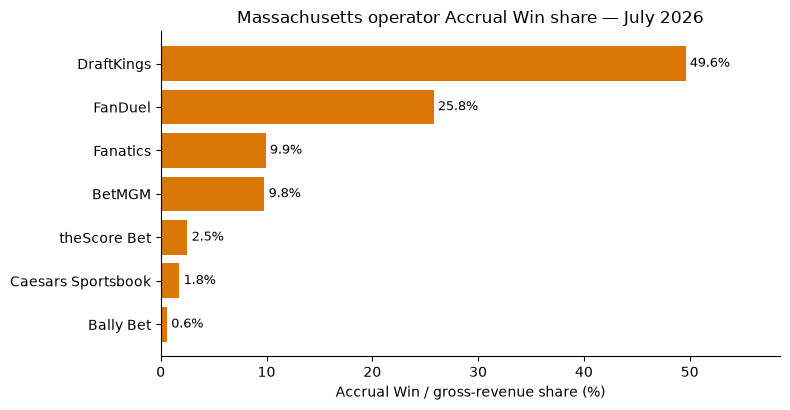

In [7]:
latest_ma_month = ma_monthly["period_start"].iloc[-1]
latest_ma_label = latest_ma_month.strftime("%B %Y")
print(f"Latest Massachusetts reporting month: {latest_ma_label}")
assert latest_ma_label == "July 2026", f"Expected July 2026 as latest MA month, got {latest_ma_label}"

ma_latest_ops = ma_operators.loc[
    pd.to_datetime(ma_operators["period_start"]) == latest_ma_month
].copy()
handle_total = float(ma_latest_ops["handle"].sum())
gross_total = float(ma_latest_ops["gross_revenue"].sum())
taxable_total = float(ma_latest_ops["taxable_revenue"].sum())
gross_hold_pct = 100.0 * gross_total / handle_total

print(
    f"{latest_ma_label} statewide: handle=${handle_total:,.2f}; "
    f"Accrual Win=${gross_total:,.2f}; taxable=${taxable_total:,.2f}; "
    f"gross hold={gross_hold_pct:.2f}%"
)

ma_shares = ma_latest_ops.loc[
    :, ["operator", "handle", "gross_revenue", "taxable_revenue"]
].copy()
ma_shares["handle_share_pct"] = 100.0 * ma_shares["handle"] / handle_total
ma_shares["gross_revenue_share_pct"] = 100.0 * ma_shares["gross_revenue"] / gross_total
ma_shares["taxable_revenue_share_pct"] = 100.0 * ma_shares["taxable_revenue"] / taxable_total
ma_shares["gross_hold_pct"] = 100.0 * ma_shares["gross_revenue"] / ma_shares["handle"]
ma_shares = ma_shares.sort_values("gross_revenue_share_pct", ascending=False).reset_index(drop=True)
display(ma_shares)

plot_frame = ma_shares.sort_values("gross_revenue_share_pct")
fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(plot_frame["operator"], plot_frame["gross_revenue_share_pct"], color=COLOR_ACCRUAL)
ax.set_xlabel("Accrual Win / gross-revenue share (%)")
ax.set_title(f"Massachusetts operator Accrual Win share — {latest_ma_label}")
ax.set_xlim(0, plot_frame["gross_revenue_share_pct"].max() * 1.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
for bar, value in zip(bars, plot_frame["gross_revenue_share_pct"]):
    ax.text(
        value + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        fontsize=9,
    )
fig.tight_layout()
plt.show()


## Comparable multi-state online sportsbooks (monthly GGR only)

This section compares states that report **monthly online sportsbook GGR with usable handle**.

Inclusion rules (all required):

- `vertical == "online_sports_betting"`
- `frequency == "monthly"`
- `revenue_basis == "GGR"`
- positive, non-null handle
- non-null revenue

Massachusetts now qualifies through these general rules: Accrual Win is stored in `gross_revenue`, so consolidation labels MA `revenue_basis == "GGR"`, and settled handle is populated. No MA special-case filter is required.

Illinois AGR, Iowa/Louisiana net proceeds, and other non-GGR bases remain excluded. New Jersey sportsbook GGR is repaired and valid for GGR trends and operator share, but remains excluded here because official handle is unavailable.


Note: NJ sportsbook GGR is repaired and valid for GGR trends and operator share, but 98 aggregated state-month observation(s) are excluded from this handle-plus-GGR comparison (98 with missing or non-positive handle).
July 2026 comparable handle-plus-GGR cohort (8): CT, DC, IN, MA, MI, NC, NH, OH
Latest max-coverage month: July 2026 (8 comparable GGR states)
Same-month comparison: July 2026 vs July 2025
Trailing 12 months ending July 2026 vs preceding 12 months (Aug 2025-Jul 2026 vs Aug 2024-Jul 2025)
Computed observations (descriptive, not causal):
- Largest comparable market by trailing-12M handle: OH ($10.20B).
- Fastest trailing-12M handle growth: DC (+45.6%). Note: this growth comes from a much smaller handle base.
- GGR growth most exceeds handle growth: MI (GGR +34.5% vs handle +4.2%; hold change +287 bps).
- Handle growth most exceeds GGR growth: DC (handle +45.6% vs GGR +38.6%; hold change -49 bps).


,state,handle,GGR,hold_pct,handle_yoy_pct,ggr_yoy_pct,hold_change_bps
0,OH,$0.62B,$66.5M,10.78%,+18.2%,+12.9%,-50 bps
1,MA,$0.59B,$66.5M,11.33%,+21.5%,+36.8%,+126 bps
2,NC,$0.57B,$63.2M,11.16%,+52.9%,+178.7%,+504 bps
3,IN,$0.38B,$40.8M,10.81%,+34.8%,+21.2%,-121 bps
4,MI,$0.36B,$43.4M,12.21%,+25.6%,+27.2%,+15 bps
5,CT,$0.18B,$12.7M,7.21%,+48.9%,-0.2%,-355 bps
6,NH,$0.06B,$7.3M,11.32%,+46.2%,+49.8%,+28 bps
7,DC,$0.02B,$2.3M,9.60%,+26.2%,+48.0%,+141 bps


,state,t12_handle,t12_ggr,t12_hold_pct,prior_t12_hold_pct,handle_growth_pct,ggr_growth_pct,hold_change_bps
0,OH,$10.20B,$1074.9M,10.54%,9.60%,+7.0%,+17.5%,+94 bps
1,MA,$8.53B,$883.3M,10.35%,9.87%,+8.7%,+14.0%,+48 bps
2,NC,$7.82B,$835.3M,10.68%,9.42%,+17.3%,+33.0%,+126 bps
3,IN,$5.73B,$571.7M,9.97%,9.43%,+6.1%,+12.2%,+54 bps
4,MI,$5.61B,$713.7M,12.71%,9.85%,+4.2%,+34.5%,+287 bps
5,CT,$2.45B,$203.3M,8.31%,8.84%,+12.3%,+5.5%,-54 bps
6,NH,$0.88B,$102.1M,11.66%,11.32%,+18.5%,+22.1%,+34 bps
7,DC,$0.34B,$33.4M,9.78%,10.27%,+45.6%,+38.6%,-49 bps


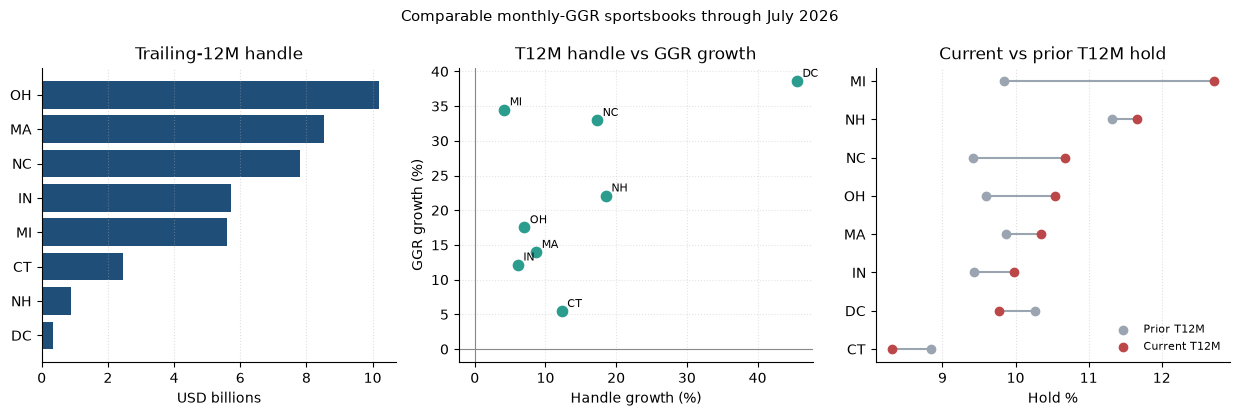

In [8]:
comparable = state_period.loc[
    (state_period["vertical"] == "online_sports_betting")
    & (state_period["frequency"] == "monthly")
    & (state_period["revenue_basis"] == "GGR")
].copy()
comparable["period_start"] = pd.to_datetime(comparable["period_start"])
comparable["handle"] = pd.to_numeric(comparable["handle"], errors="coerce")
comparable["revenue"] = pd.to_numeric(comparable["revenue"], errors="coerce")

valid_ggr = comparable.loc[
    comparable["handle"].notna()
    & (comparable["handle"] > 0)
    & comparable["revenue"].notna()
].copy()

# NJ sportsbook GGR is repaired and valid, but official handle is unavailable on
# aggregated state-month sportsbook rows. The general missing-handle filter excludes NJ.
nj_candidates = comparable.loc[comparable["state_code"] == "NJ"].copy()
nj_excluded = nj_candidates.loc[
    ~(
        nj_candidates["handle"].notna()
        & (nj_candidates["handle"] > 0)
        & nj_candidates["revenue"].notna()
    )
].copy()
if not nj_excluded.empty:
    missing_or_nonpositive_handle = int(
        (~nj_excluded["handle"].notna() | ~(nj_excluded["handle"] > 0)).sum()
    )
    missing_revenue = int((~nj_excluded["revenue"].notna()).sum())
    reasons = []
    if missing_or_nonpositive_handle:
        reasons.append(
            f"{missing_or_nonpositive_handle} with missing or non-positive handle"
        )
    if missing_revenue:
        reasons.append(f"{missing_revenue} with missing revenue")
    print(
        "Note: NJ sportsbook GGR is repaired and valid for GGR trends and operator share, "
        f"but {len(nj_excluded)} aggregated state-month observation(s) are excluded from this "
        f"handle-plus-GGR comparison ({'; '.join(reasons)})."
    )

july_2026 = pd.Timestamp("2026-07-01")
july_cohort = sorted(
    valid_ggr.loc[valid_ggr["period_start"] == july_2026, "state_code"].unique()
)
expected_july_cohort = ["CT", "DC", "IN", "MA", "MI", "NC", "NH", "OH"]
assert july_cohort == expected_july_cohort, (
    f"July 2026 comparable cohort {july_cohort} != {expected_july_cohort}"
)
assert len(july_cohort) == 8
print(f"July 2026 comparable handle-plus-GGR cohort ({len(july_cohort)}): {', '.join(july_cohort)}")

coverage_by_month = (
    valid_ggr.groupby("period_start")["state_code"].nunique().sort_index()
)
max_coverage = int(coverage_by_month.max())
compare_month = coverage_by_month[coverage_by_month == max_coverage].index.max()
prior_month = compare_month - pd.DateOffset(years=1)
compare_label = compare_month.strftime("%B %Y")
prior_label = prior_month.strftime("%B %Y")
print(
    f"Latest max-coverage month: {compare_label} "
    f"({max_coverage} comparable GGR states)"
)

current = valid_ggr.loc[valid_ggr["period_start"] == compare_month].set_index("state_code")
prior = valid_ggr.loc[valid_ggr["period_start"] == prior_month].set_index("state_code")
states = sorted(set(current.index).intersection(prior.index))

yoys = []
for state in states:
    handle_now = float(current.loc[state, "handle"])
    ggr_now = float(current.loc[state, "revenue"])
    handle_prev = float(prior.loc[state, "handle"])
    ggr_prev = float(prior.loc[state, "revenue"])
    hold_now = 100.0 * ggr_now / handle_now
    hold_prev = 100.0 * ggr_prev / handle_prev
    yoys.append(
        {
            "state": state,
            "handle": handle_now,
            "GGR": ggr_now,
            "hold_pct": hold_now,
            "handle_yoy_pct": 100.0 * (handle_now / handle_prev - 1.0),
            "ggr_yoy_pct": 100.0 * (ggr_now / ggr_prev - 1.0),
            "hold_change_bps": (hold_now - hold_prev) * 100.0,
        }
    )
monthly_yoy = pd.DataFrame(yoys).sort_values("handle", ascending=False).reset_index(drop=True)

def trailing_windows(end_month: pd.Timestamp):
    current_start = end_month - pd.DateOffset(months=11)
    prior_end = end_month - pd.DateOffset(years=1)
    prior_start = prior_end - pd.DateOffset(months=11)
    return current_start, end_month, prior_start, prior_end

t12_start, t12_end, p12_start, p12_end = trailing_windows(compare_month)
expected_current_months = pd.date_range(t12_start, t12_end, freq="MS")
expected_prior_months = pd.date_range(p12_start, p12_end, freq="MS")


def exact_month_window(group: pd.DataFrame, expected_months: pd.DatetimeIndex) -> pd.DataFrame | None:
    """Require every expected month exactly once; fail closed on gaps or duplicates."""
    window = group.loc[group["period_start"].isin(expected_months)].copy()
    month_counts = window["period_start"].value_counts()
    if set(window["period_start"]) != set(expected_months):
        return None
    if not (month_counts == 1).all():
        return None
    if len(window) != len(expected_months):
        return None
    return window.sort_values("period_start")


t12_rows = []
for state, group in valid_ggr.groupby("state_code"):
    current_window = exact_month_window(group, expected_current_months)
    prior_window = exact_month_window(group, expected_prior_months)
    if current_window is None or prior_window is None:
        continue
    handle_now = float(current_window["handle"].sum())
    ggr_now = float(current_window["revenue"].sum())
    handle_prev = float(prior_window["handle"].sum())
    ggr_prev = float(prior_window["revenue"].sum())
    hold_now = 100.0 * ggr_now / handle_now
    hold_prev = 100.0 * ggr_prev / handle_prev
    t12_rows.append(
        {
            "state": state,
            "t12_handle": handle_now,
            "t12_ggr": ggr_now,
            "t12_hold_pct": hold_now,
            "prior_t12_hold_pct": hold_prev,
            "handle_growth_pct": 100.0 * (handle_now / handle_prev - 1.0),
            "ggr_growth_pct": 100.0 * (ggr_now / ggr_prev - 1.0),
            "hold_change_bps": (hold_now - hold_prev) * 100.0,
        }
    )
trailing_12 = pd.DataFrame(t12_rows).sort_values("t12_handle", ascending=False).reset_index(drop=True)

print(f"Same-month comparison: {compare_label} vs {prior_label}")
display(
    monthly_yoy.assign(
        handle=lambda d: d["handle"].map(lambda x: f"${x/1e9:.2f}B"),
        GGR=lambda d: d["GGR"].map(lambda x: f"${x/1e6:.1f}M"),
        hold_pct=lambda d: d["hold_pct"].map(lambda x: f"{x:.2f}%"),
        handle_yoy_pct=lambda d: d["handle_yoy_pct"].map(lambda x: f"{x:+.1f}%"),
        ggr_yoy_pct=lambda d: d["ggr_yoy_pct"].map(lambda x: f"{x:+.1f}%"),
        hold_change_bps=lambda d: d["hold_change_bps"].map(lambda x: f"{x:+.0f} bps"),
    )
)
print(
    f"Trailing 12 months ending {compare_label} vs preceding 12 months "
    f"({t12_start.strftime('%b %Y')}-{t12_end.strftime('%b %Y')} vs "
    f"{p12_start.strftime('%b %Y')}-{p12_end.strftime('%b %Y')})"
)
display(
    trailing_12.assign(
        t12_handle=lambda d: d["t12_handle"].map(lambda x: f"${x/1e9:.2f}B"),
        t12_ggr=lambda d: d["t12_ggr"].map(lambda x: f"${x/1e6:.1f}M"),
        t12_hold_pct=lambda d: d["t12_hold_pct"].map(lambda x: f"{x:.2f}%"),
        prior_t12_hold_pct=lambda d: d["prior_t12_hold_pct"].map(lambda x: f"{x:.2f}%"),
        handle_growth_pct=lambda d: d["handle_growth_pct"].map(lambda x: f"{x:+.1f}%"),
        ggr_growth_pct=lambda d: d["ggr_growth_pct"].map(lambda x: f"{x:+.1f}%"),
        hold_change_bps=lambda d: d["hold_change_bps"].map(lambda x: f"{x:+.0f} bps"),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))

t12_plot = trailing_12.sort_values("t12_handle")
axes[0].barh(t12_plot["state"], t12_plot["t12_handle"] / 1e9, color=COLOR_HANDLE)
axes[0].set_xlabel("USD billions")
axes[0].set_title("Trailing-12M handle")
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)
axes[0].grid(axis="x", linestyle=":", alpha=0.4)

axes[1].axhline(0, color="#888888", linewidth=0.8)
axes[1].axvline(0, color="#888888", linewidth=0.8)
axes[1].scatter(
    trailing_12["handle_growth_pct"],
    trailing_12["ggr_growth_pct"],
    s=55,
    color=COLOR_TAXABLE,
    zorder=3,
)
for _, row in trailing_12.iterrows():
    axes[1].annotate(
        row["state"],
        (row["handle_growth_pct"], row["ggr_growth_pct"]),
        fontsize=8,
        xytext=(4, 3),
        textcoords="offset points",
    )
axes[1].set_xlabel("Handle growth (%)")
axes[1].set_ylabel("GGR growth (%)")
axes[1].set_title("T12M handle vs GGR growth")
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)
axes[1].grid(linestyle=":", alpha=0.35)

hold_plot = trailing_12.sort_values("t12_hold_pct")
y = range(len(hold_plot))
axes[2].hlines(y, hold_plot["prior_t12_hold_pct"], hold_plot["t12_hold_pct"], color="#9aa5b1", linewidth=1.5)
axes[2].scatter(hold_plot["prior_t12_hold_pct"], y, color="#9aa5b1", label="Prior T12M", zorder=3)
axes[2].scatter(hold_plot["t12_hold_pct"], y, color=COLOR_HOLD, label="Current T12M", zorder=3)
axes[2].set_yticks(list(y))
axes[2].set_yticklabels(hold_plot["state"])
axes[2].set_xlabel("Hold %")
axes[2].set_title("Current vs prior T12M hold")
axes[2].legend(frameon=False, fontsize=8, loc="lower right")
axes[2].spines["top"].set_visible(False)
axes[2].spines["right"].set_visible(False)
axes[2].grid(axis="x", linestyle=":", alpha=0.4)

fig.suptitle(f"Comparable monthly-GGR sportsbooks through {compare_label}", fontsize=11)
fig.tight_layout()
plt.show()

largest = trailing_12.iloc[0]
fastest = trailing_12.sort_values("handle_growth_pct", ascending=False).iloc[0]
median_handle = float(trailing_12["t12_handle"].median())
ggr_over_handle = (
    trailing_12.assign(gap=lambda d: d["ggr_growth_pct"] - d["handle_growth_pct"])
    .sort_values("gap", ascending=False)
    .iloc[0]
)
handle_over_ggr = (
    trailing_12.assign(gap=lambda d: d["handle_growth_pct"] - d["ggr_growth_pct"])
    .sort_values("gap", ascending=False)
    .iloc[0]
)

print("Computed observations (descriptive, not causal):")
print(
    f"- Largest comparable market by trailing-12M handle: {largest['state']} "
    f"(${largest['t12_handle']/1e9:.2f}B)."
)
small_base_note = (
    " Note: this growth comes from a much smaller handle base."
    if fastest["t12_handle"] < 0.5 * median_handle
    else ""
)
print(
    f"- Fastest trailing-12M handle growth: {fastest['state']} "
    f"({fastest['handle_growth_pct']:+.1f}%).{small_base_note}"
)
print(
    f"- GGR growth most exceeds handle growth: {ggr_over_handle['state']} "
    f"(GGR {ggr_over_handle['ggr_growth_pct']:+.1f}% vs handle {ggr_over_handle['handle_growth_pct']:+.1f}%; "
    f"hold change {ggr_over_handle['hold_change_bps']:+.0f} bps)."
)
print(
    f"- Handle growth most exceeds GGR growth: {handle_over_ggr['state']} "
    f"(handle {handle_over_ggr['handle_growth_pct']:+.1f}% vs GGR {handle_over_ggr['ggr_growth_pct']:+.1f}%; "
    f"hold change {handle_over_ggr['hold_change_bps']:+.0f} bps)."
)

connection.close()


## Basic observations and limits

The cells above inventory SQLite coverage, rebuild latest analytical views with the existing consolidate helpers, walk through Massachusetts Accrual Win trends, and compare monthly GGR sportsbook states with usable handle.

**Revenue-basis limitation.** GGR / Accrual Win, AGR, taxable revenue, and net proceeds are different metrics and must not be mixed. Massachusetts stores Accrual Win in `gross_revenue` and Taxable Gaming Revenue separately in `taxable_revenue`; hold uses Accrual Win / settled handle. Handle-only states remain outside revenue comparisons.

**Reporting-lag limitation.** "Latest month" means the latest *available* official month with usable data, not the current calendar month.

**New Jersey limitation.** NJ sportsbook GGR is repaired and valid for GGR trends and operator share. NJ remains excluded from handle and hold comparisons because official handle is unavailable on its aggregated state-month sportsbook rows; the general missing-handle filter enforces that exclusion.

**What to do next.** Choose the next analytical question (seasonality, operator continuity, or another PDF state) before promoting more plotting helpers into modules.
